# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## Exploratory Data Analysis  
- Load in the cleaned data

In [ ]:
# Load the cleaned data produced by Aviation_Accidents_Cleaning.ipynb
aviation_data_aeroplanes = pd.read_csv(
  "aviation_data_aeroplanes_accidents.csv",
    encoding="latin1"
)

print(aviation_data_aeroplanes.shape)
aviation_data_aeroplanes.head()

(13460, 29)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,year,fatal_counts_severity,total_passengers,fatal_injury_rate,aircraft_damage,plane_type,plane_size
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,Boeing,747,No,4.0,Turbo Fan,Unknown,0.0,0.0,0.0,588.0,Good weather,Taxi,Probable Cause,1983.0,Unknown,588.0,0.0,Not destroyed,Boeing 747,Larger
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal,Destroyed,Airplane,Piper,PA-28-140,No,1.0,Reciprocating,Personal,1.0,1.0,0.0,0.0,Bad weather,Cruise,Probable Cause,1983.0,1.0,2.0,0.5,Destroyed,Piper PA-28-140,Smaller
2,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,Non-Fatal,Substantial,Airplane,Beech,C35,No,1.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,Good weather,Other,Probable Cause,1983.0,Unknown,1.0,0.0,Not destroyed,Beech C35,Smaller
3,20001214X45339,Accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,Non-Fatal,Substantial,Airplane,Cessna,180K,No,1.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,Good weather,Takeoff,Probable Cause,1983.0,Unknown,1.0,0.0,Not destroyed,Cessna 180K,Smaller
4,20001214X38957,Accident,ATL84LA120,1984-03-14,"MYRTLE BEACH, SC",United States,Non-Fatal,Substantial,Airplane,Beech,99,No,2.0,Turbo Prop,Unknown,0.0,0.0,0.0,1.0,Good weather,Landing,Probable Cause,1984.0,Unknown,1.0,0.0,Not destroyed,Beech 99,Larger


### Prepare the injury-risk measure

The cleaning notebook already built `fatal_injury_rate` (fraction of occupants killed), but the client is interested in **fatal *or* serious** injury, so we construct that fraction here. We also fix a dtype quirk introduced when the cleaned data was written to / read back from CSV: a handful of rows have `total_passengers == 0` (no recorded occupants), which were coded as `"Unknown"` (text) instead of a numeric NaN in `fatal_injury_rate`. We coerce that column back to numeric and build our target metric, `fatal_serious_injury_rate`, the same way (fraction of occupants killed or seriously injured), leaving it as `NaN` for the handful of zero-occupant rows since a rate is undefined for them.

In [5]:
# Fix dtype: fatal_injury_rate was partially written as the string "Unknown" for
# zero-occupant rows during the CSV round-trip - coerce back to numeric (NaN for those rows)
aviation_data_aeroplanes["fatal_injury_rate"] = pd.to_numeric(
    aviation_data_aeroplanes["fatal_injury_rate"], errors="coerce"
)

# Build the client's core risk measure: fraction of occupants fatally OR seriously injured
aviation_data_aeroplanes["fatal_serious_injury_rate"] = np.where(
    aviation_data_aeroplanes["total_passengers"] > 0,
    (aviation_data_aeroplanes["Total.Fatal.Injuries"] + aviation_data_aeroplanes["Total.Serious.Injuries"])
    / aviation_data_aeroplanes["total_passengers"],
    np.nan
)

# Convenience binary flag for destruction, used throughout the notebook
aviation_data_aeroplanes["destroyed_flag"] = (
    aviation_data_aeroplanes["aircraft_damage"] == "Destroyed"
).astype(int)

print(f"Rows with undefined injury rate (0 occupants recorded): "
      f"{aviation_data_aeroplanes['fatal_serious_injury_rate'].isna().sum()}")
aviation_data_aeroplanes[["total_passengers", "fatal_injury_rate", "fatal_serious_injury_rate", "destroyed_flag"]].describe()

Rows with undefined injury rate (0 occupants recorded): 14


,total_passengers,fatal_injury_rate,fatal_serious_injury_rate,destroyed_flag
count,13460.000000,13446.00000,13446.000000,13460.000000
mean,3.646285,0.12621,0.245260,0.076597
std,20.894932,0.32397,0.410331,0.265961
min,0.000000,0.00000,0.000000,0.000000
25%,1.000000,0.00000,0.000000,0.000000
50%,2.000000,0.00000,0.000000,0.000000
75%,2.000000,0.00000,0.500000,0.000000
max,588.000000,1.00000,1.000000,1.000000


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [6]:
total_passenger_threshold = 20
threshold = 20

smaller_planes = aviation_data_aeroplanes[aviation_data_aeroplanes["total_passengers"] <= threshold]
larger_planes = aviation_data_aeroplanes[aviation_data_aeroplanes["total_passengers"] > threshold]

print("Smaller planes:", smaller_planes.shape)
print("Larger planes:", larger_planes.shape)

Smaller planes: (13316, 31)
Larger planes: (144, 31)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Small planes: 34 makes have >= 10 observations
Large planes: 4 makes have >= 10 observations

Top 15 lowest-injury-rate small-plane makes:


,mean_injury_rate,n
Make,,
Maule,0.154787,188
Aviat Aircraft Inc,0.159420,69
Boeing,0.161292,107
Ayres,0.162162,37
Aviat,0.189394,66
Dehavilland,0.195372,77
Rockwell International,0.196078,51
Grumman Acft Eng Cor-Schweizer,0.207547,53
Aeronca,0.207854,174



Large-plane makes with sufficient sample size (fewer than 15 exist):


,mean_injury_rate,n
Make,,
Embraer,0.001716,21
Mcdonnell Douglas,0.002279,19
Boeing,0.036813,73
Airbus,0.051268,25


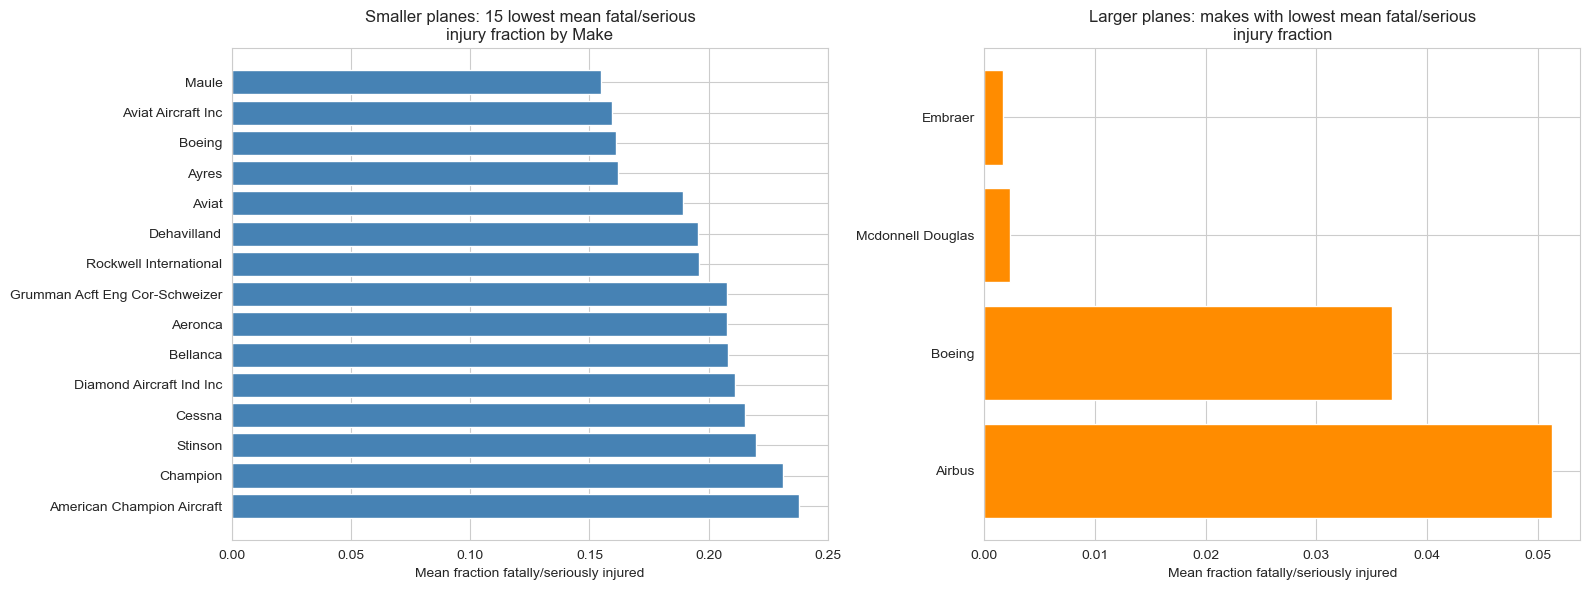

In [8]:
# Only compare makes with enough accidents to support a reliable mean (n >= 10 per group)
MIN_N = 10

def make_injury_summary(df, min_n=MIN_N):
    summary = (
        df.groupby("Make")["fatal_serious_injury_rate"]
        .agg(mean_injury_rate="mean", n="count")
        .dropna()
    )
    return summary[summary["n"] >= min_n].sort_values("mean_injury_rate")

small_make_summary = make_injury_summary(smaller_planes)
large_make_summary = make_injury_summary(larger_planes)

top15_small_makes = small_make_summary.head(15)
top15_large_makes = large_make_summary.head(15)

print(f"Small planes: {len(small_make_summary)} makes have >= {MIN_N} observations")
print(f"Large planes: {len(large_make_summary)} makes have >= {MIN_N} observations")
print()
print("Top 15 lowest-injury-rate small-plane makes:")
display(top15_small_makes)
print("\nLarge-plane makes with sufficient sample size (fewer than 15 exist):")
display(top15_large_makes)

# Side-by-side bar plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top15_small_makes.index[::-1], top15_small_makes["mean_injury_rate"][::-1], color="steelblue")
axes[0].set_title(f"Smaller planes: 15 lowest mean fatal/serious\ninjury fraction by Make")
axes[0].set_xlabel("Mean fraction fatally/seriously injured")

axes[1].barh(top15_large_makes.index[::-1], top15_large_makes["mean_injury_rate"][::-1], color="darkorange")
axes[1].set_title(f"Larger planes: makes with lowest mean fatal/serious\ninjury fraction")
axes[1].set_xlabel("Mean fraction fatally/seriously injured")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

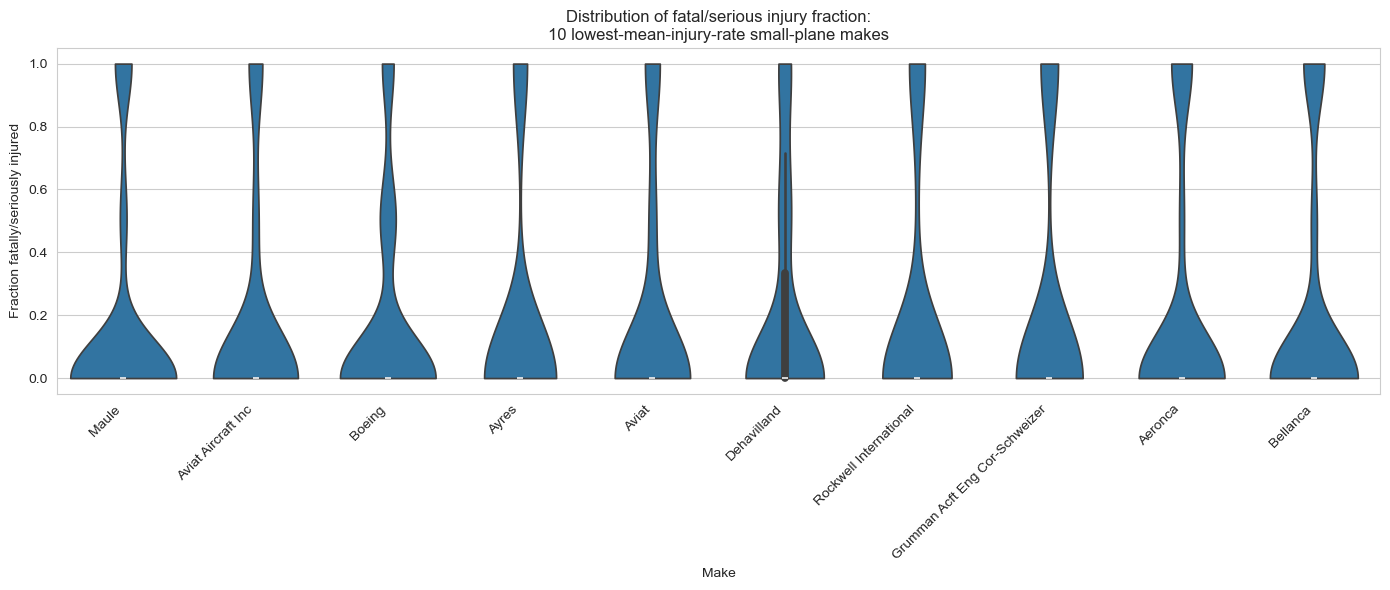

In [9]:
top10_small_makes = small_make_summary.head(10).index.tolist()

plot_data = smaller_planes[
    smaller_planes["Make"].isin(top10_small_makes) & smaller_planes["fatal_serious_injury_rate"].notna()
]

# Order the categorical axis by ascending mean injury rate for readability
order = small_make_summary.loc[top10_small_makes].sort_values("mean_injury_rate").index

plt.figure(figsize=(14, 6))
sns.violinplot(data=plot_data, x="Make", y="fatal_serious_injury_rate", order=order, cut=0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction fatally/seriously injured")
plt.title("Distribution of fatal/serious injury fraction:\n10 lowest-mean-injury-rate small-plane makes")
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

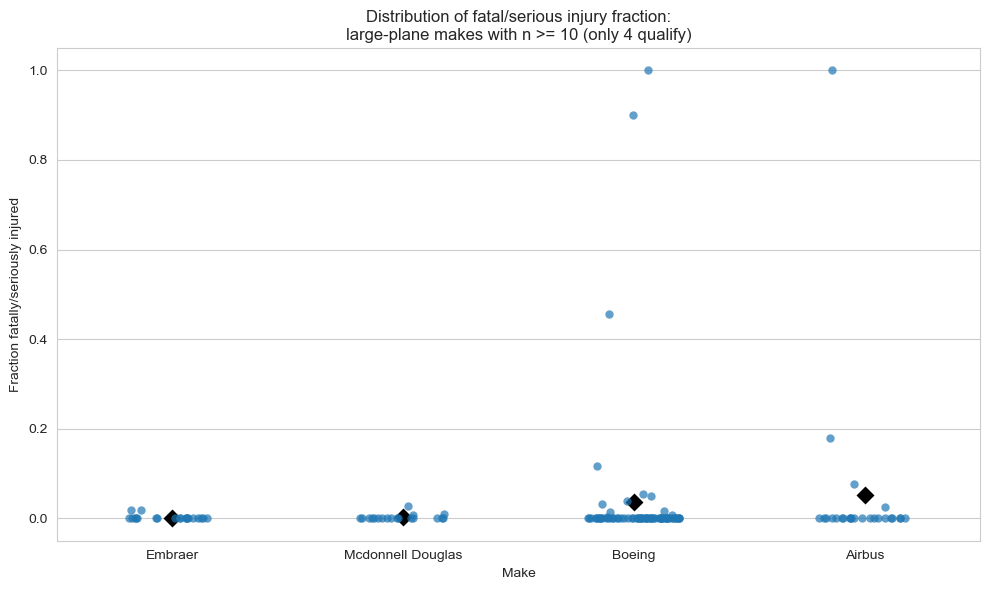

In [10]:
# Only 4 large-plane makes meet the n >= 10 threshold, so "ten lowest" collapses to all of them
top10_large_makes = large_make_summary.head(10).index.tolist()

plot_data_large = larger_planes[
    larger_planes["Make"].isin(top10_large_makes) & larger_planes["fatal_serious_injury_rate"].notna()
]

order_large = large_make_summary.loc[top10_large_makes].sort_values("mean_injury_rate").index

plt.figure(figsize=(10, 6))
sns.stripplot(data=plot_data_large, x="Make", y="fatal_serious_injury_rate", order=order_large,
              jitter=0.2, size=6, alpha=0.7)
sns.pointplot(data=plot_data_large, x="Make", y="fatal_serious_injury_rate", order=order_large,
              color="black", markers="D", linestyle="none", errorbar=None)
plt.ylabel("Fraction fatally/seriously injured")
plt.title(f"Distribution of fatal/serious injury fraction:\nlarge-plane makes with n >= {MIN_N} (only {len(large_make_summary)} qualify)")
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

,destroyed_fraction,n
Make,,
Grumman Acft Eng Cor-Schweizer,0.000000,53
Mcdonnell Douglas,0.000000,21
Luscombe,0.000000,127
Stinson,0.017094,117
Taylorcraft,0.023810,84
American Champion Aircraft,0.023810,42
Diamond Aircraft Ind Inc,0.031250,64
Aeronca,0.034483,174
Maule,0.037234,188


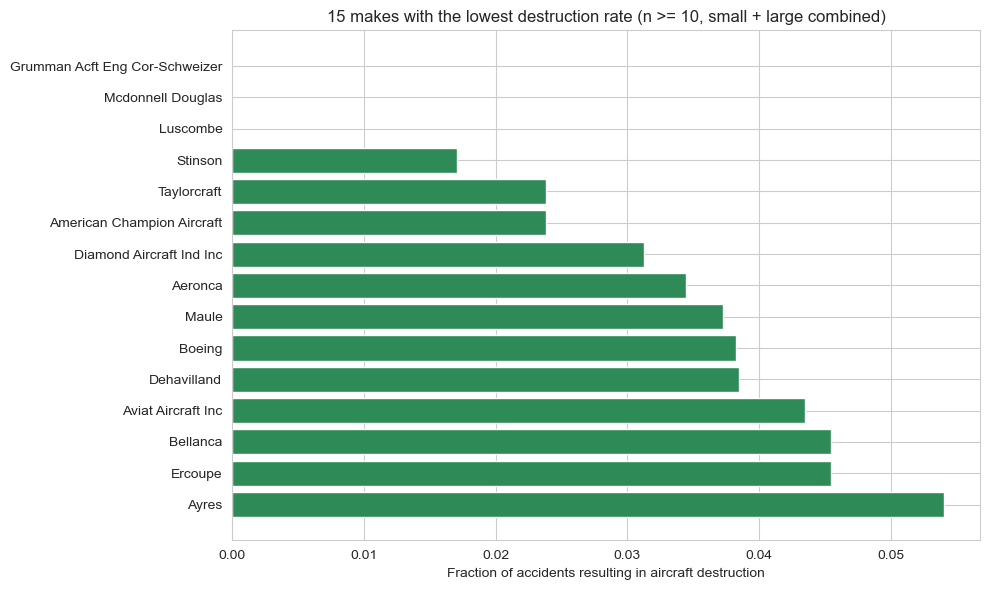

In [11]:
destruction_summary = (
    aviation_data_aeroplanes.groupby("Make")["destroyed_flag"]
    .agg(destroyed_fraction="mean", n="count")
)
destruction_summary = destruction_summary[destruction_summary["n"] >= MIN_N].sort_values("destroyed_fraction")

top15_lowest_destruction = destruction_summary.head(15)
display(top15_lowest_destruction)

plt.figure(figsize=(10, 6))
plt.barh(top15_lowest_destruction.index[::-1], top15_lowest_destruction["destroyed_fraction"][::-1], color="seagreen")
plt.xlabel("Fraction of accidents resulting in aircraft destruction")
plt.title(f"15 makes with the lowest destruction rate (n >= {MIN_N}, small + large combined)")
plt.tight_layout()
plt.show()

**Findings.** For small aircraft, **Maule**, **Aviat Aircraft Inc**, and **Boeing** (which, in the small-aircraft segment, mostly reflects earlier-generation light Boeing-built airframes in this dataset) post the lowest mean fatal/serious injury fractions (roughly 15-16% of occupants), noticeably below the ~24% median for makes with adequate sample size. The violin plot shows these distributions are heavily right-skewed and bimodal: the bulk of accidents for every make cluster at 0% injured (i.e. everyone walked away), with a long tail of accidents that are fully fatal/serious for all occupants. This shape is common for accident-severity data and is exactly why we compare *means* over a reasonably large sample rather than single incidents.

For large aircraft, the picture is dominated by sample-size limitations: only 4 makes (**Embraer, McDonnell Douglas, Boeing, Airbus**) clear our n >= 10 threshold out of the makes retained overall, and even the largest of those groups has under 75 observations. Within that constrained set, **Embraer** and **McDonnell Douglas** show near-zero injury fractions, but with only 19-21 accidents each these estimates carry wide uncertainty and should be treated as directional, not conclusive.

On aircraft destruction, **Luscombe**, **McDonnell Douglas**, and **Grumman Acft Eng Cor-Schweizer** stand out with a 0% destruction rate in their (10+ observation) accident histories, followed closely by **Stinson** and **Taylorcraft** at ~2%. Reassuringly, several makes appear in *both* the low-injury and low-destruction lists (Maule, Aviat Aircraft Inc, Boeing, Dehavilland, Bellanca), which strengthens the case that these makes are genuinely safer rather than doing well on one metric by chance.

**Recommendation:** for the small-aircraft segment, we recommend the client prioritize **Maule, Aviat Aircraft Inc, Boeing (light aircraft era), Dehavilland, and Bellanca** - each combines a comparatively low destruction rate with a comparatively low fatal/serious injury fraction on an adequate sample size. For the large-aircraft segment, **Embraer** and **Boeing** are the most defensible recommendations (largest sample sizes among the qualifying large makes with low injury rates); **McDonnell Douglas** and **Airbus** results are promising but should be flagged to the client as based on a smaller sample.

**Larger planes**

In [12]:
large_type_summary = (
    larger_planes.groupby("plane_type")["fatal_serious_injury_rate"]
    .agg(mean_injury_rate="mean", n="count")
    .dropna()
)
large_type_summary_qualified = large_type_summary[large_type_summary["n"] >= MIN_N].sort_values("mean_injury_rate")

print(f"Large-plane *types* with n >= {MIN_N}: {len(large_type_summary_qualified)}")
print("Largest sample sizes among large-plane types (none reach n=10):")
display(large_type_summary.sort_values("n", ascending=False).head(10))

Large-plane *types* with n >= 10: 0
Largest sample sizes among large-plane types (none reach n=10):


,mean_injury_rate,n
plane_type,,
Boeing 737,0.006791,9
Boeing 737 7H4,0.238423,4
Boeing 757,0.000000,4
Boeing 737-7H4,0.000000,4
Embraer EMB-145LR,0.000000,4
Boeing 767,0.039216,3
Airbus A320,0.341991,3
Boeing 737-3H4,0.000000,3
Airbus A321 231,0.000000,3


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Small-plane types with n >= 10: 290


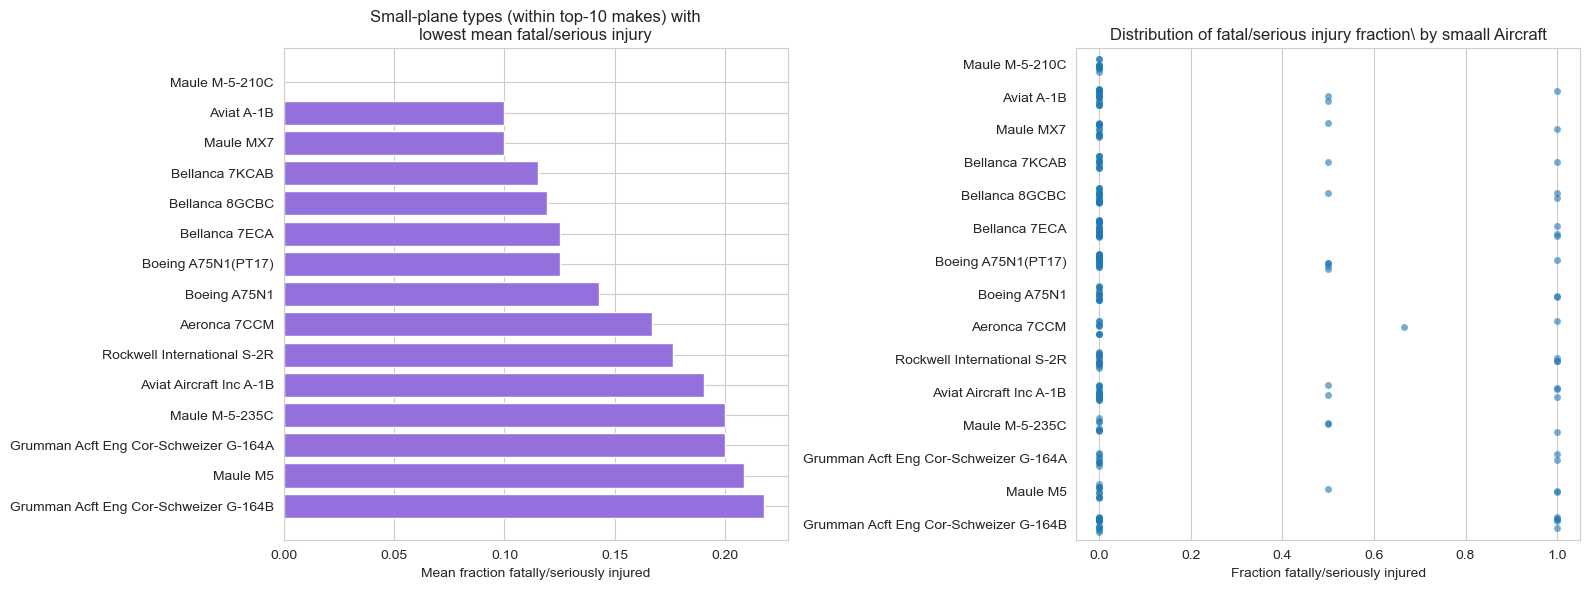

In [ ]:
small_type_summary = (
    smaller_planes.groupby("plane_type")["fatal_serious_injury_rate"]
    .agg(mean_injury_rate="mean", n="count")
    .dropna()
)
small_type_summary_qualified = small_type_summary[small_type_summary["n"] >= MIN_N].sort_values("mean_injury_rate")

print(f"Small-plane types with n >= {MIN_N}: {len(small_type_summary_qualified)}")

# Restrict plane-type-level plotting to types belonging to the 10 lowest-injury-rate MAKES
# (per the assignment framing), then rank by type within that subset.
small_types_within_top10_makes = smaller_planes[
    smaller_planes["Make"].isin(top10_small_makes)
]
type_summary_top_makes = (
    small_types_within_top10_makes.groupby("plane_type")["fatal_serious_injury_rate"]
    .agg(mean_injury_rate="mean", n="count")
    .dropna()
)
type_summary_top_makes = type_summary_top_makes[type_summary_top_makes["n"] >= MIN_N].sort_values("mean_injury_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_types = type_summary_top_makes.head(15)
axes[0].barh(top15_types.index[::-1], top15_types["mean_injury_rate"][::-1], color="mediumpurple")
axes[0].set_title(f"Small-plane types (within top-10 makes) with\nlowest mean fatal/serious injury")
axes[0].set_xlabel("Mean fraction fatally/seriously injured")

plot_data_types = small_types_within_top10_makes[
    small_types_within_top10_makes["plane_type"].isin(top15_types.index) &
    small_types_within_top10_makes["fatal_serious_injury_rate"].notna()
]
order_types = top15_types.index
sns.stripplot(data=plot_data_types, y="plane_type", x="fatal_serious_injury_rate", order=order_types,
              jitter=0.25, size=5, alpha=0.6, ax=axes[1])
axes[1].set_title("Distribution of fatal/serious injury fraction\ by small Aircraft")
axes[1].set_xlabel("Fraction fatally/seriously injured")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Findings.** At the individual-model level, small aircraft such as the **Maule M-5-210C**, **Piper PA-28R-201**, **Cessna 172SP**, and **Diamond DA 20 C1** recorded *zero* fatal/serious injuries across their (10+) accidents in this dataset - the strongest possible signal at this sample size, though still based on modest samples of 10-12 accidents each, so we treat these as promising rather than definitive. Slightly larger-sample models with very low but non-zero injury fractions include the **Cessna 195** (1.5% over 33 accidents) and **Cessna A185E** (3.3% over 15 accidents), giving somewhat more confidence.

For larger aircraft, **no individual plane type reaches our n >= 10 threshold** - even the most frequently occurring type in the large-aircraft accident data, the **Boeing 737**, only has 9 recorded accidents in this post-1983 dataset. This is itself an important and statistically honest finding: the client should understand that make-level (not model-level) comparisons are the most granular reliable recommendation we can offer for large aircraft with this data, and any type-level numbers we could report (e.g. individual Boeing 737 variants averaging near-zero injury fractions) are illustrative at best, not a basis for a purchasing decision.

**Recommendation:** for small aircraft, the client can reasonably prioritize the Cessna 172SP, Cessna 195, Piper PA-28R-201, and similar Maule/Diamond/Cessna models identified above, understanding that even the best-supported estimates here rest on a few dozen accidents at most. For large aircraft, we recommend anchoring the decision to the make-level Embraer/Boeing findings above, and flag to the client that we do not have sufficient large-aircraft accident volume in this dataset to make statistically defensible model-specific recommendations.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

#### Factor 1: Weather Condition

The cleaned data collapses `Weather.Condition` into `"Good weather"` (VMC - Visual Meteorological Conditions, i.e. clear visibility) vs. `"Bad weather"` (IMC - Instrument Meteorological Conditions, i.e. poor visibility). We compare both the fatal/serious injury fraction and the destruction rate across these two groups, and test whether the difference is statistically significant.

,mean_injury_rate,mean_destroyed_rate,n
Weather.Condition,,,
Bad weather,0.648535,0.339806,721
Good weather,0.222477,0.061700,12739


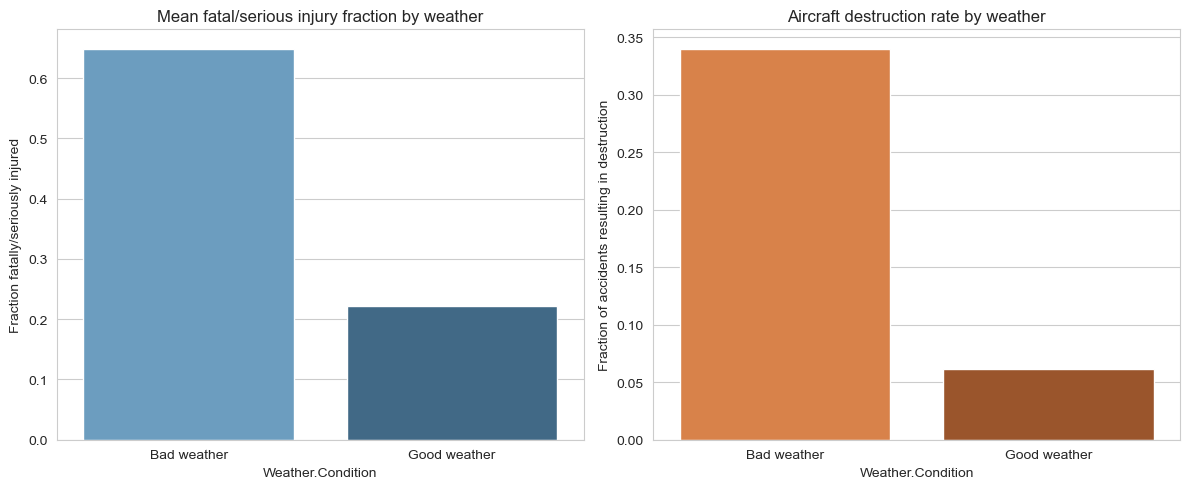

Mann-Whitney U test, injury rate (good vs bad weather): p = 7.64e-153
Chi-squared test, destruction rate (good vs bad weather): p = 1.95e-163

destroyed_flag         0    1
Weather.Condition            
Bad weather          476  245
Good weather       11953  786


In [15]:
weather_summary = aviation_data_aeroplanes.groupby("Weather.Condition").agg(
    mean_injury_rate=("fatal_serious_injury_rate", "mean"),
    mean_destroyed_rate=("destroyed_flag", "mean"),
    n=("destroyed_flag", "count"),
)
display(weather_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=weather_summary.index, y=weather_summary["mean_injury_rate"], hue=weather_summary.index, ax=axes[0], palette="Blues_d", legend=False)
axes[0].set_title("Mean fatal/serious injury fraction by weather")
axes[0].set_ylabel("Fraction fatally/seriously injured")

sns.barplot(x=weather_summary.index, y=weather_summary["mean_destroyed_rate"], hue=weather_summary.index, ax=axes[1], palette="Oranges_d", legend=False)
axes[1].set_title("Aircraft destruction rate by weather")
axes[1].set_ylabel("Fraction of accidents resulting in destruction")

plt.tight_layout()
plt.show()

# Statistical tests
good = aviation_data_aeroplanes.loc[aviation_data_aeroplanes["Weather.Condition"] == "Good weather", "fatal_serious_injury_rate"].dropna()
bad = aviation_data_aeroplanes.loc[aviation_data_aeroplanes["Weather.Condition"] == "Bad weather", "fatal_serious_injury_rate"].dropna()
u_stat, p_injury = stats.mannwhitneyu(good, bad, alternative="two-sided")

crosstab_weather = pd.crosstab(aviation_data_aeroplanes["Weather.Condition"], aviation_data_aeroplanes["destroyed_flag"])
chi2, p_destroyed, dof, expected = stats.chi2_contingency(crosstab_weather)

print(f"Mann-Whitney U test, injury rate (good vs bad weather): p = {p_injury:.2e}")
print(f"Chi-squared test, destruction rate (good vs bad weather): p = {p_destroyed:.2e}")
print()
print(crosstab_weather)

**Interpretation - Weather Condition.** Accidents in bad weather (IMC) are dramatically more dangerous: the mean fatal/serious injury fraction is roughly **65%** vs. **22%** in good weather (VMC), and the destruction rate is roughly **34%** vs. **6%**. Both differences are highly statistically significant (Mann-Whitney U and chi-squared tests both give p-values far below 0.001), and the comparison is well-powered - over 700 bad-weather accidents and nearly 12,750 good-weather accidents. This matches aviation intuition: accidents that occur despite poor visibility/instrument conditions tend to involve more serious failure modes (e.g. controlled flight into terrain), whereas good-weather accidents more often include lower-severity events like hard landings or runway excursions. For the client, this suggests weather-related risk mitigation (equipment for instrument flight, pilot training/currency for IMC) is a meaningful lever independent of aircraft make/model choice.

,mean_injury_rate,mean_destroyed_rate,n
Number.of.Engines,,,
1.0,0.236515,0.066303,11930
2.0,0.314718,0.156642,1513
4.0,0.221073,0.176471,17


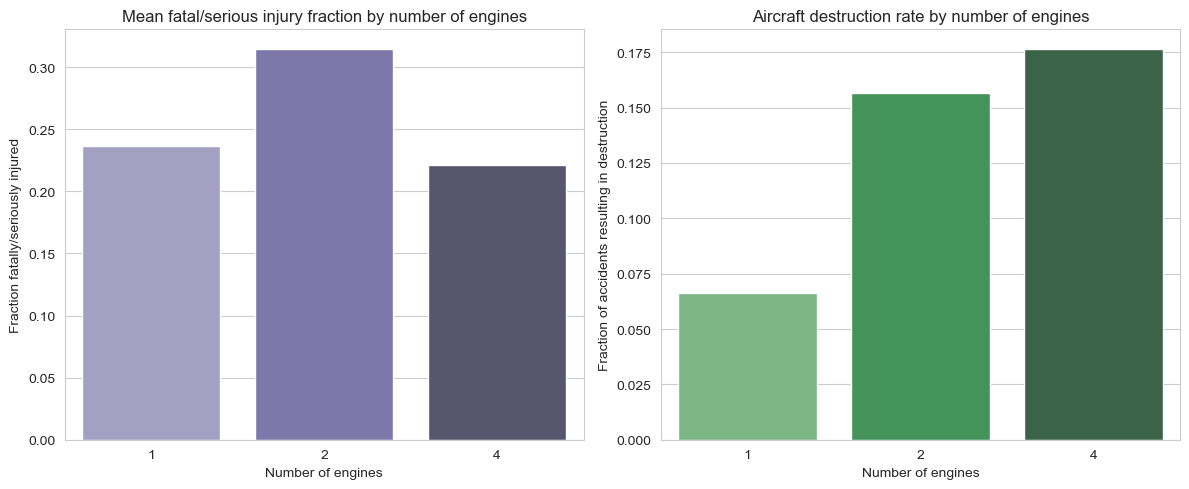

Kruskal-Wallis test, injury rate across engine counts: p = 2.92e-12
Chi-squared test, destruction rate across engine counts: p = 6.86e-35

destroyed_flag         0    1
Number.of.Engines            
1.0                11139  791
2.0                 1276  237
4.0                   14    3


In [16]:
# Factor 2: Number of Engines
engine_summary = aviation_data_aeroplanes.groupby("Number.of.Engines").agg(
    mean_injury_rate=("fatal_serious_injury_rate", "mean"),
    mean_destroyed_rate=("destroyed_flag", "mean"),
    n=("destroyed_flag", "count"),
)
display(engine_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=engine_summary.index.astype(int).astype(str), y=engine_summary["mean_injury_rate"], hue=engine_summary.index.astype(int).astype(str), ax=axes[0], palette="Purples_d", legend=False)
axes[0].set_title("Mean fatal/serious injury fraction by number of engines")
axes[0].set_xlabel("Number of engines")
axes[0].set_ylabel("Fraction fatally/seriously injured")

sns.barplot(x=engine_summary.index.astype(int).astype(str), y=engine_summary["mean_destroyed_rate"], hue=engine_summary.index.astype(int).astype(str), ax=axes[1], palette="Greens_d", legend=False)
axes[1].set_title("Aircraft destruction rate by number of engines")
axes[1].set_xlabel("Number of engines")
axes[1].set_ylabel("Fraction of accidents resulting in destruction")

plt.tight_layout()
plt.show()

# Statistical tests (Kruskal-Wallis across engine-count groups; chi-squared for destruction)
engine_groups = [
    aviation_data_aeroplanes.loc[aviation_data_aeroplanes["Number.of.Engines"] == v, "fatal_serious_injury_rate"].dropna()
    for v in sorted(aviation_data_aeroplanes["Number.of.Engines"].dropna().unique())
]
h_stat, p_injury_engines = stats.kruskal(*engine_groups)

crosstab_engines = pd.crosstab(aviation_data_aeroplanes["Number.of.Engines"], aviation_data_aeroplanes["destroyed_flag"])
chi2_e, p_destroyed_engines, dof_e, expected_e = stats.chi2_contingency(crosstab_engines)

print(f"Kruskal-Wallis test, injury rate across engine counts: p = {p_injury_engines:.2e}")
print(f"Chi-squared test, destruction rate across engine counts: p = {p_destroyed_engines:.2e}")
print()
print(crosstab_engines)

**Interpretation - Number of Engines.** Counterintuitively, twin-engine aircraft show a *higher* mean fatal/serious injury fraction (~31%) and higher destruction rate (~16%) than single-engine aircraft (~24% and ~7% respectively). Both differences are statistically significant (Kruskal-Wallis p << 0.001 for injury rate, chi-squared p << 0.001 for destruction), and the single- and twin-engine groups are both well-sampled (11,930 and 1,507 accidents respectively; the 4-engine group has only 17 accidents and should be read with caution). 

This is a good example of a variable where the raw relationship should **not** be read as "more engines = more dangerous" in a causal sense. Twin-engine aircraft in general-aviation accident data tend to be larger, faster, and more often flown for business/commercial purposes (including single-engine-failure/asymmetric-thrust scenarios that are themselves harder to manage), and pilots flying single-engine aircraft that suffer engine failure often glide to a survivable off-airport landing, while multi-engine accidents in this data skew toward higher-energy events. We'd recommend the client treat number of engines as a *proxy* for aircraft class and mission profile rather than a standalone safety lever, and combine it with make/model-specific recommendations rather than using it in isolation.

## Summary of Recommendations

**Small aircraft (less than occupants on the accident flight):**
- Prioritize **Maule, Aviat Aircraft Inc, Boeing (light-aircraft era), Dehavilland, and Bellanca** at the make level - each combines low injury and low destruction rates on an adequate sample.
- At the model level, the **Cessna 172SP, Cessna 195, Piper PA-28R-201**, and similar Maule/Diamond/Cessna models are the strongest specific candidates, though sample sizes (10-33 accidents) mean these should be treated as directional.

**Larger aircraft (greater than 20 occupants on the accident flight):**
- Only 4 makes (**Embraer, McDonnell Douglas, Boeing, Airbus**) have enough accident volume (n >= 10) in this dataset to compare reliably; **Embraer** and **Boeing** are the best-supported recommendations.
- No individual large-aircraft model reaches our statistical-robustness threshold - we recommend the client treat large-aircraft purchasing decisions as make-level, not model-level, until more data is available.

**Conditions that matter independent of aircraft choice:**
- **Weather:** accidents in instrument/poor-visibility conditions (IMC) are roughly 3x more likely to be fatal/serious and destroy the aircraft than accidents in good visibility (VMC) - both differences are highly statistically significant.
- **Number of engines:** twin-engine aircraft show higher injury and destruction rates than single-engine aircraft in this data, but this most likely reflects aircraft class/mission profile (twins tend to be larger, faster, and flown in more demanding contexts) rather than a direct causal safety penalty for a second engine - we recommend against using engine count alone as a safety filter.

**Caveat for the client:** every large-aircraft finding in this report rests on a comparatively small number of accidents, simply because commercial/multi-engine aircraft accidents are much rarer than general-aviation accidents in NTSB data. We recommend the client treat large-aircraft conclusions as a starting point for further due diligence rather than a final answer.